In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
import random

import itertools
import os
import pickle as pkl
from pathlib import Path
import concurrent.futures
import functools
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.ephys_plots import plot_brain_regions
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.singlecell import bin_spikes2D
from brainbox.task.trials import find_trial_ids, get_event_aligned_raster, get_psth
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from brainwidemap.bwm_loading import merge_probes
from iblatlas.atlas import AllenAtlas, BrainRegions
from matplotlib import pyplot as plt
from one.api import ONE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier
from ibl_info.selective_decomposition import filter_eids
from sklearn.svm import SVC
from tqdm import tqdm

import ibl_info.measures.information_measures as info
from ibl_info.prepare_data_pid import get_new_cinc_intervals, prepare_ephys_data
from ibl_info.utils import (
    check_config,
)
from scipy.stats import wilcoxon

In [7]:
important_regions = np.asarray(
    [
        "VISp",
        "MOs",
        "SSp-ul",
        "ACAd",
        "PL",
        "CP",
        "VPM",
        "MG",
        "LGd",
        "ZI",
        "SNr",
        "MRN",
        "SCm",
        "PAG",
        "APN",
        "RN",
        "PPN",
        "PRNc",
        "PRNr",
        "GRN",
        "IRN",
        "PGRN",
        "CUL4 5",
        "SIM",
        "IP",
    ]
)

In [ ]:
# let's do it for equi-binning



In [10]:
from glob import glob

In [161]:
def get_firing_rates(region):
    files = glob(f"../../data/generated/nofilter/equi/**/*{region}*.pkl", recursive=True)
    with open(files[0], "rb") as f:
        data = pkl.load(f)
    firing_rates = []
    for eid in data.keys():
        firing_rates.append(data[eid]["average_spikes"])
    return firing_rates

In [162]:
def collate_by_bins(files, region):

    bins = []
    for fx in files:
        with open(fx, "rb") as f:
            data = pkl.load(f)

        firing_rates = []
        congruent_mi = []
        incongruent_mi = []
        for eid in data.keys():
            if "average_spikes" not in data[eid].keys():
                firing_rates = get_firing_rates(region)
            else:
                firing_rates.append(data[eid]["average_spikes"])  # type: ignore
            congruent_mi.append(data[eid]["subsampled"]["mutual_information"])
            incongruent_mi.append(data[eid]["incongruent"]["mutual_information"])
        firing_rates = np.concatenate(firing_rates)
        congruent_mi = np.concatenate(congruent_mi)
        incongruent_mi = np.concatenate(incongruent_mi)
        sort_idx = np.argsort(firing_rates)
        firing_rates = firing_rates[sort_idx]
        congruent_mi = congruent_mi[sort_idx]
        incongruent_mi = incongruent_mi[sort_idx]
        bins.append([firing_rates, congruent_mi, incongruent_mi])
    return bins

In [163]:
def plot_mi_vs_bins(firing_rates, MI, region, typeoftrial, bin_labels=None, n_groups=3):
    """
    Plot how MI varies with number of bins and firing rate.

    Parameters
    ----------
    firing_rates : array, shape (n_neurons,)
        Firing rates per neuron.
    MI : array, shape (n_bins, n_neurons)
        Mutual information values per bin count × neuron.
    bin_labels : list, optional
        Labels for bins. If None, will use range(n_bins).
    n_groups : int
        Number of firing-rate groups to divide into.
    """
    n_bins, n_neurons = MI.shape
    if bin_labels is None:
        bin_labels = list(range(n_bins))

    # Flatten into long-form dataframe
    records = []
    for i, b in enumerate(bin_labels):
        for j in range(n_neurons):
            records.append({"bins": b, "firing_rate": firing_rates[j], "MI": MI[i, j]})
    df = pd.DataFrame(records)

    # Compute quantile bins for firing rates
    quantiles = np.linspace(0, 1, n_groups + 1)
    edges = np.quantile(firing_rates, quantiles)

    # Label by numeric thresholds
    labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f})" for i in range(len(edges) - 1)]
    df["fr_group"] = pd.cut(df["firing_rate"], bins=edges, labels=labels, include_lowest=True)

    # Plotting
    fig, axs = plt.subplots(1, 1, figsize=(8, 4))

    # 1. Boxplot grouped by firing rate
    sns.boxplot(data=df, x="fr_group", y="MI", hue="bins", ax=axs)
    axs.set_title(f"{region}-{typeoftrial}")
    axs.set_xlabel("Firing rate groups")
    axs.set_ylabel("MI")
    axs.spines["top"].set_visible(False)
    axs.spines["right"].set_visible(False)
    plt.tight_layout()

    plt.show()

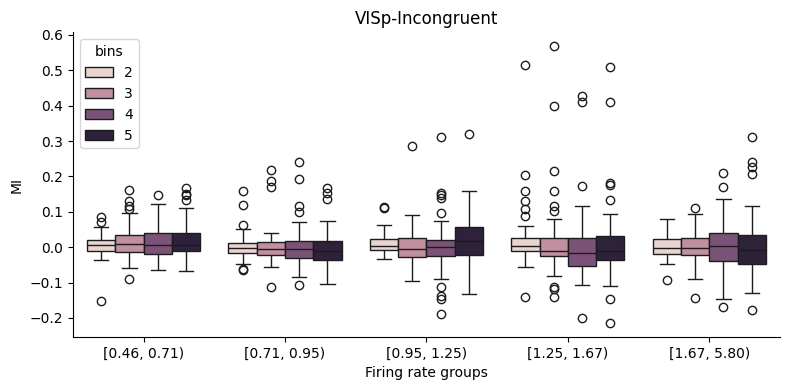

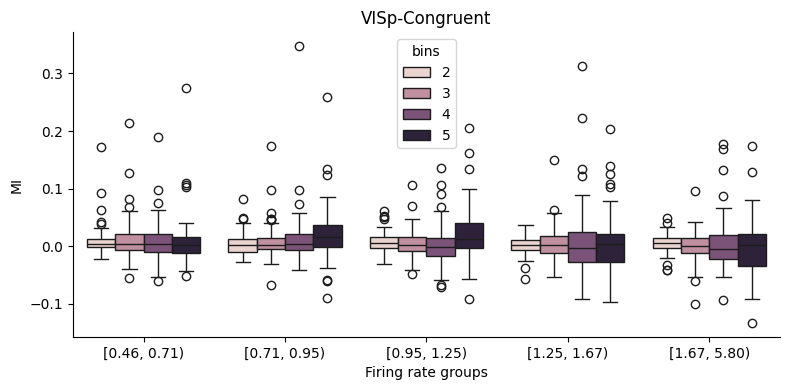

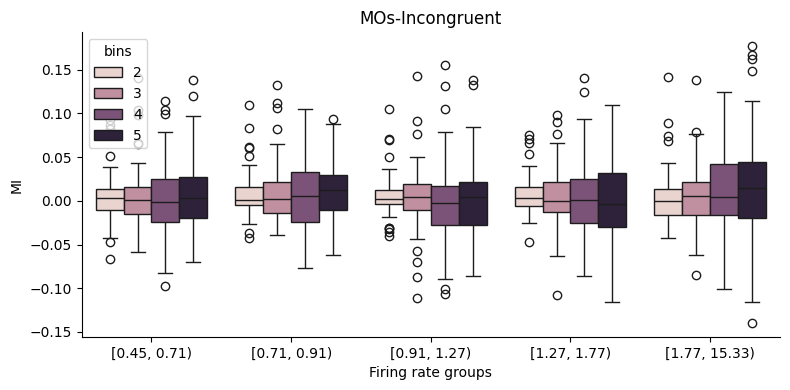

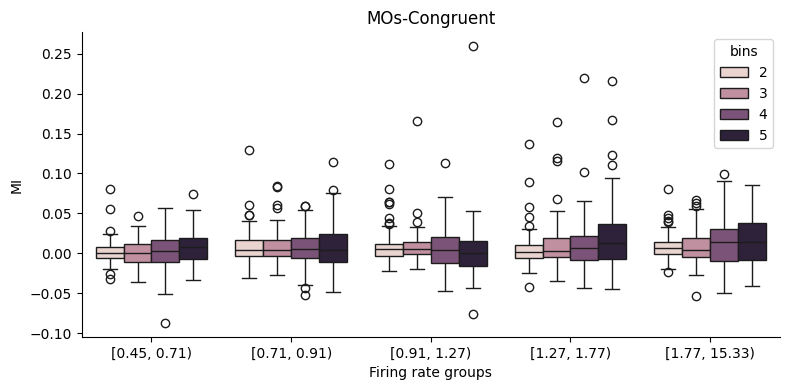

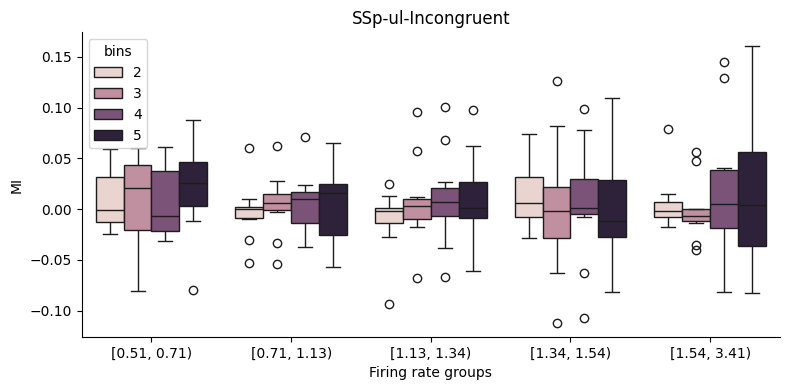

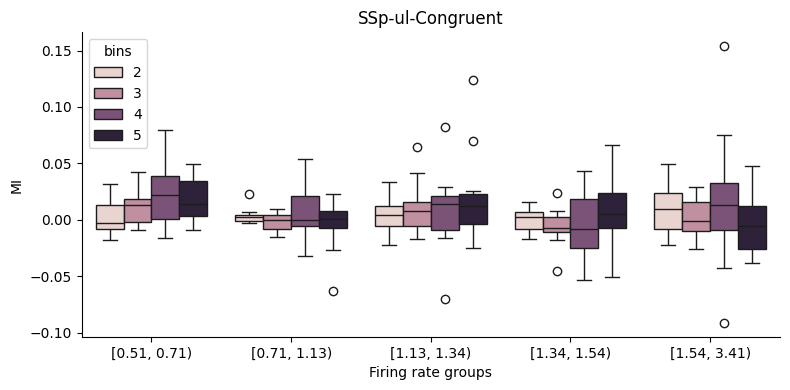

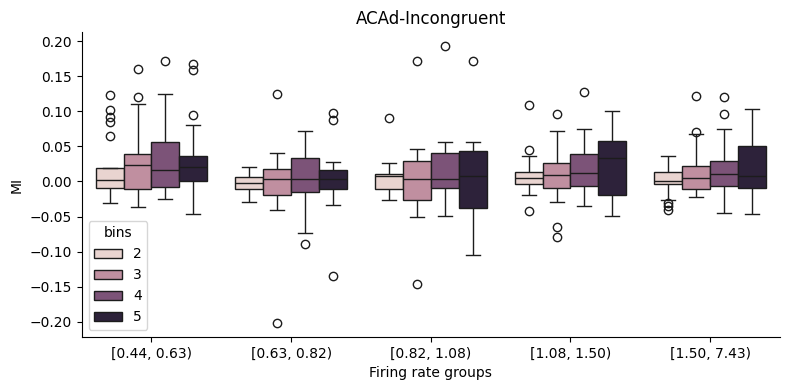

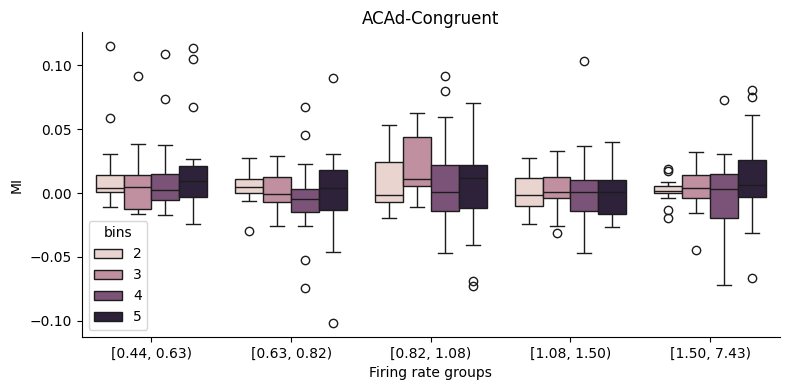

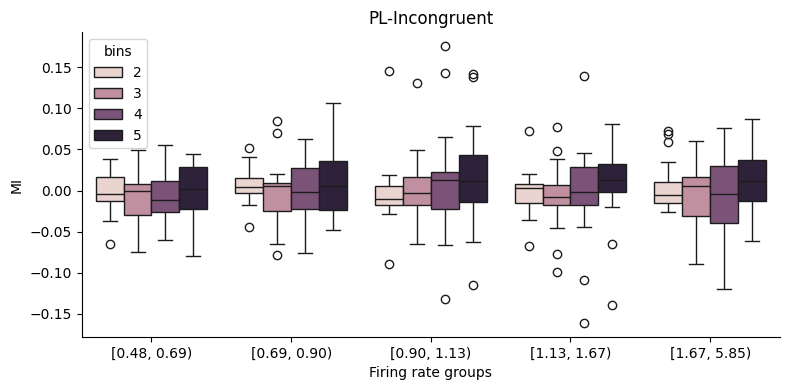

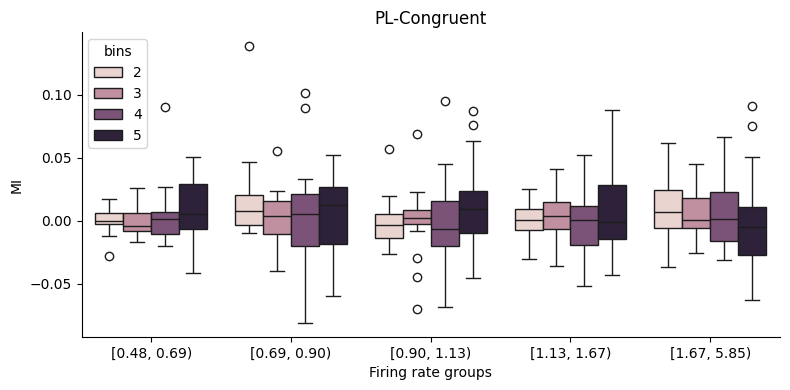

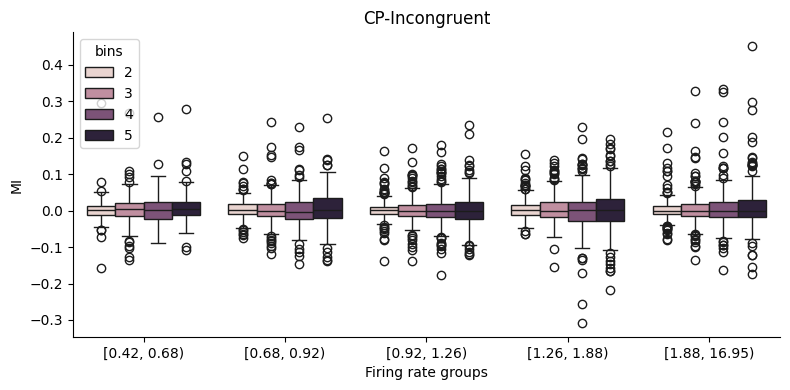

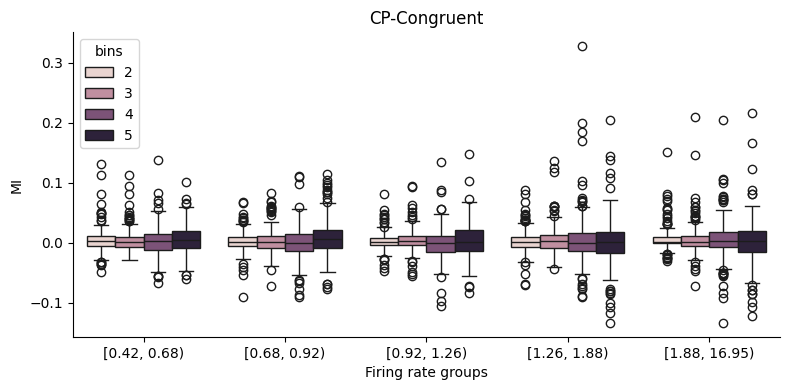

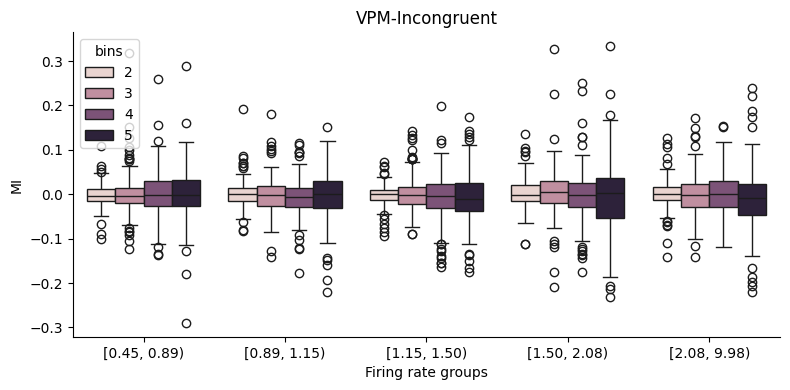

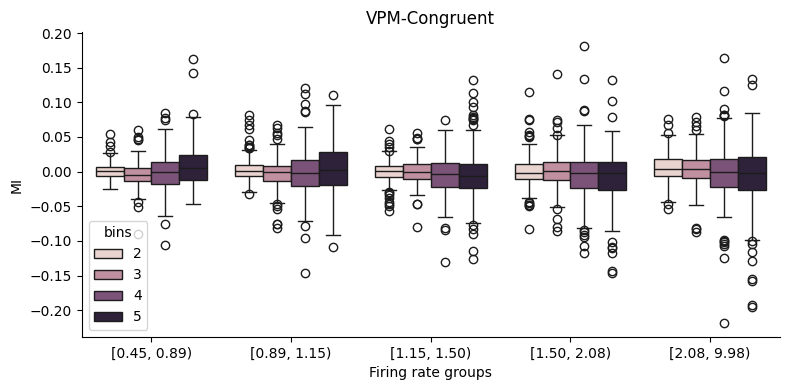

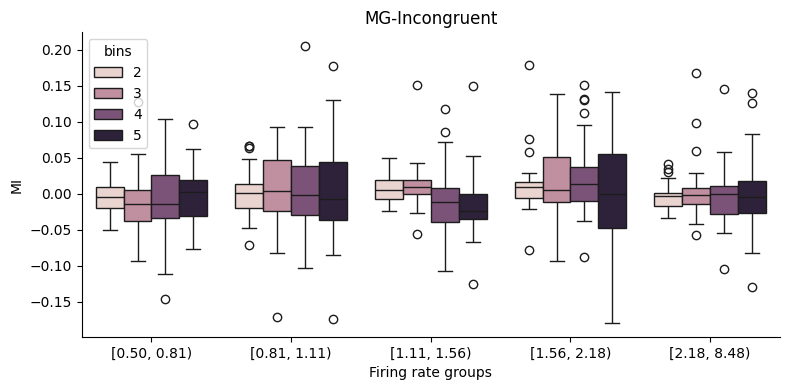

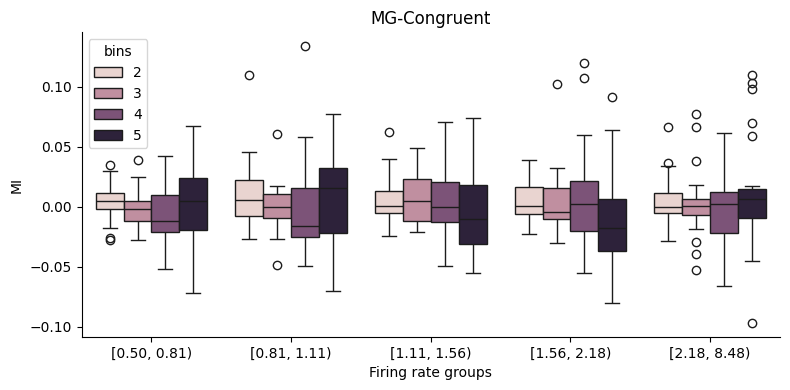

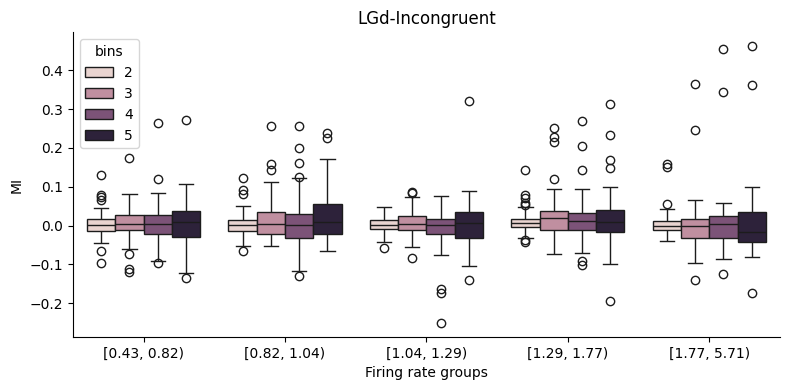

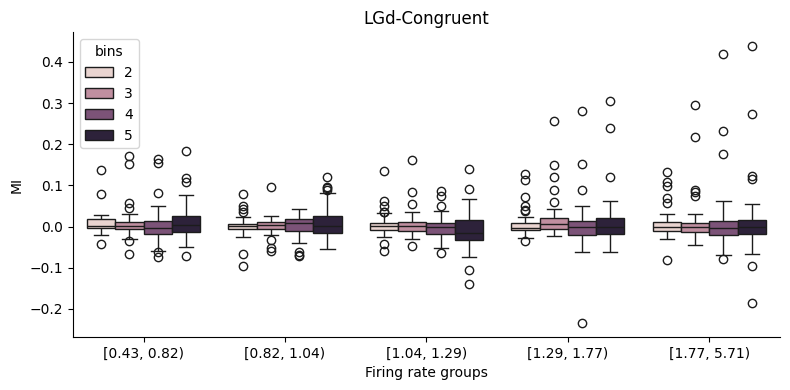

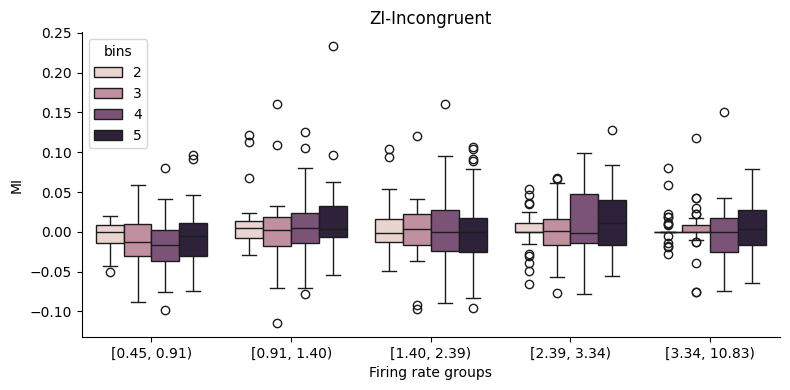

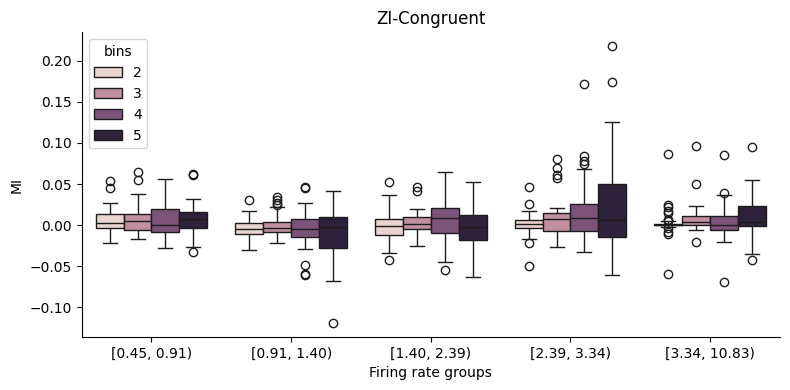

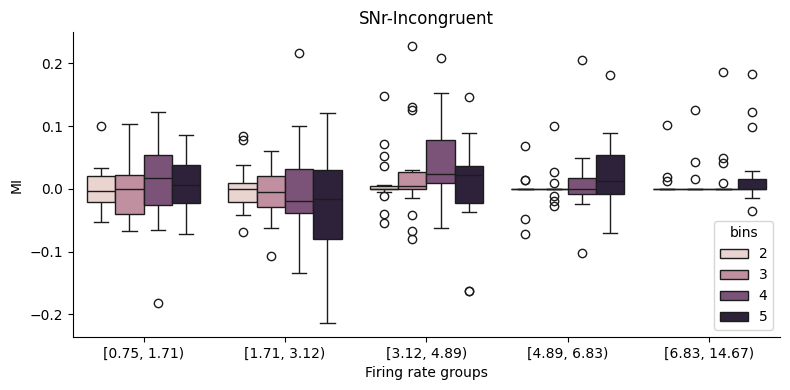

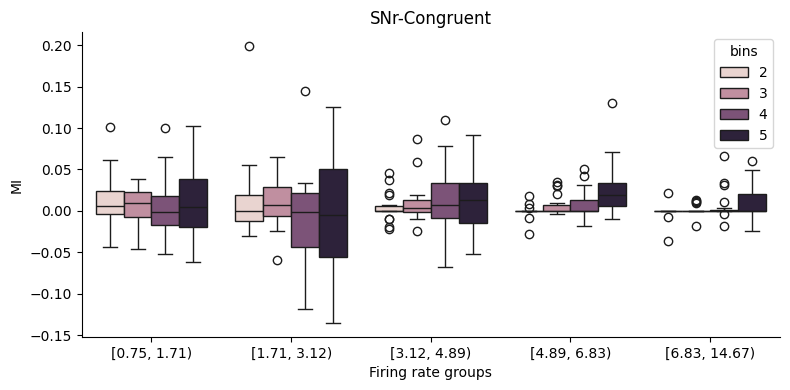

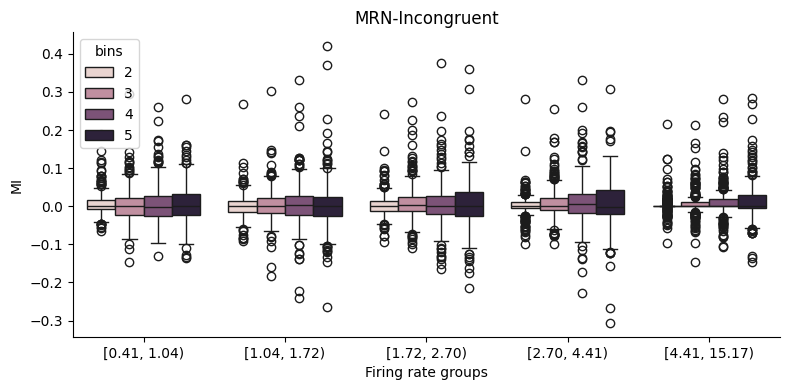

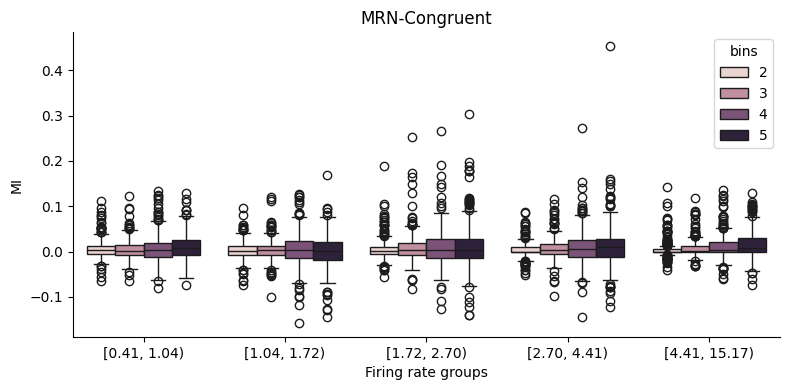

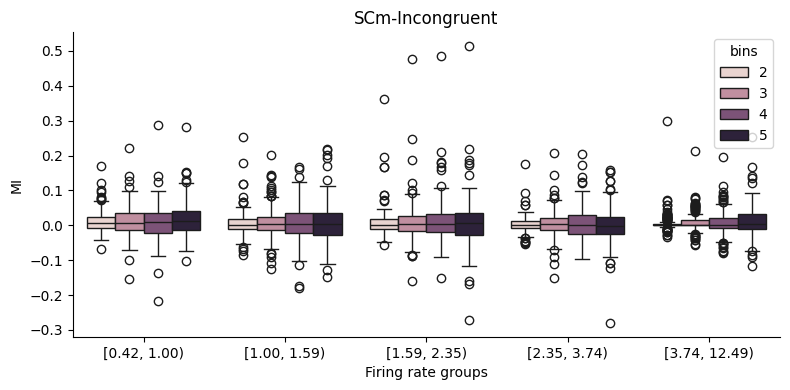

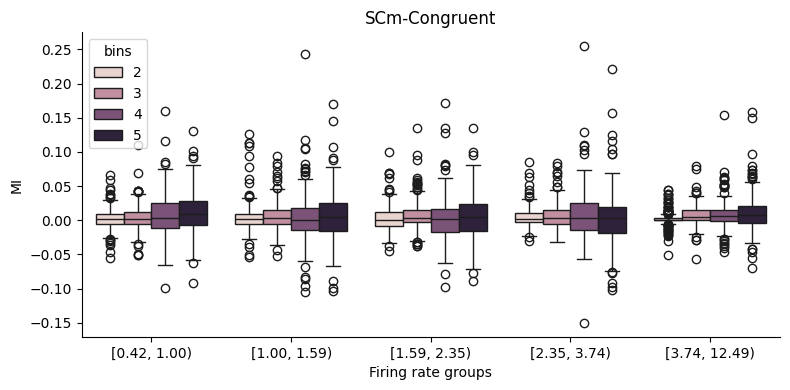

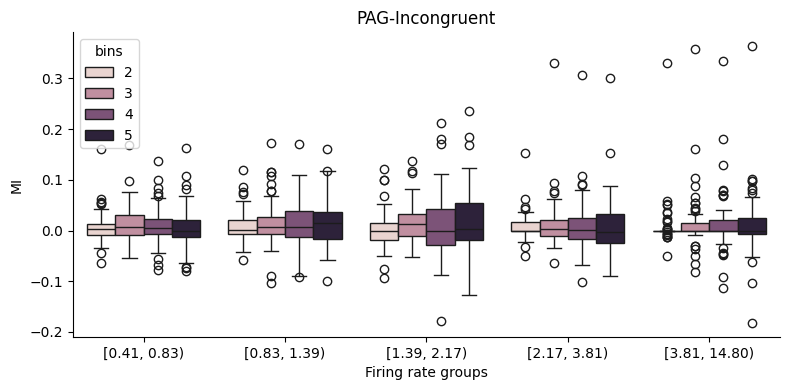

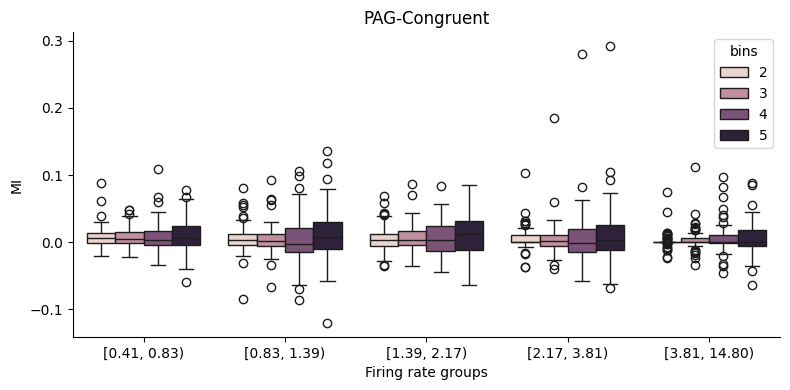

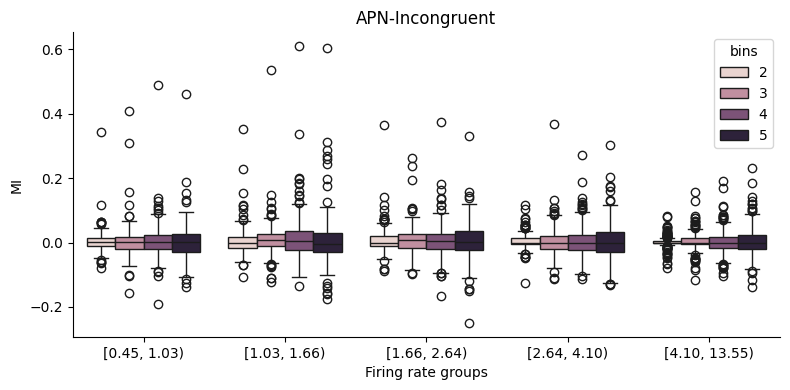

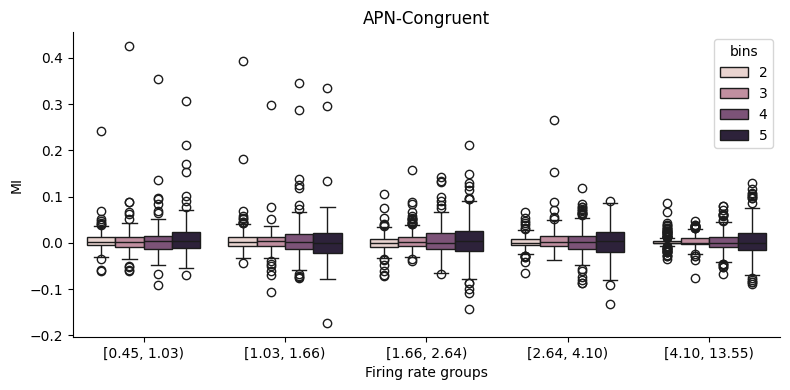

index 47 is out of bounds for axis 0 with size 47


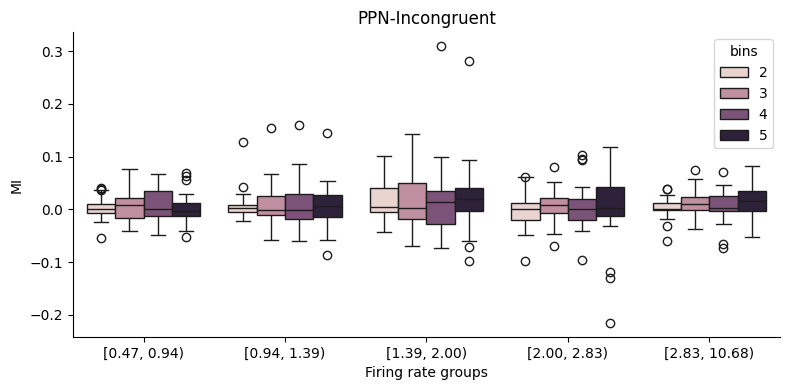

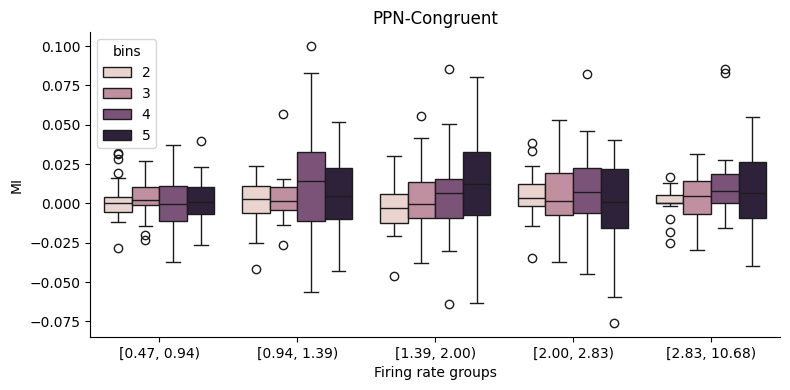

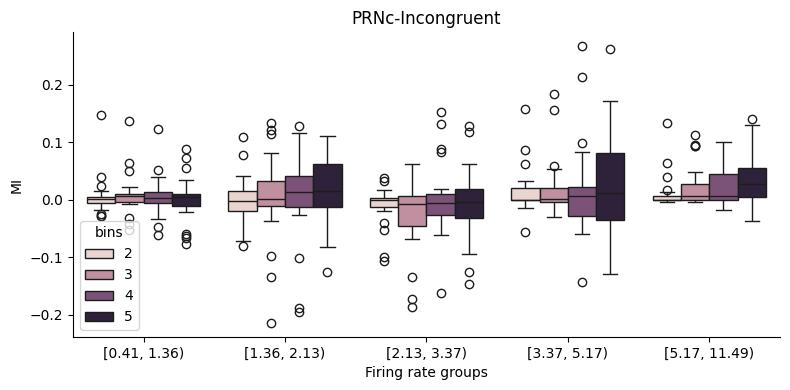

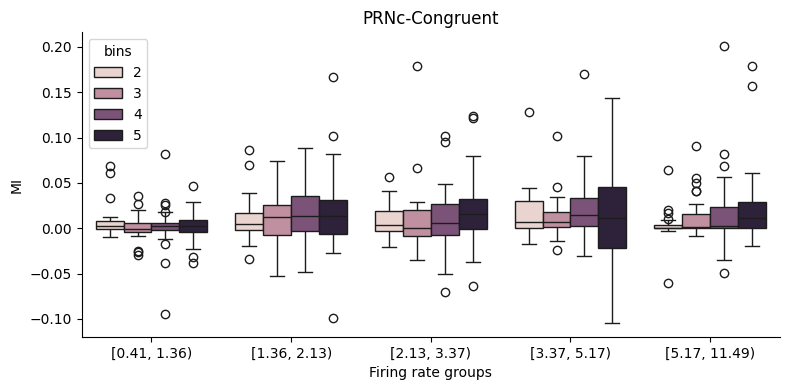

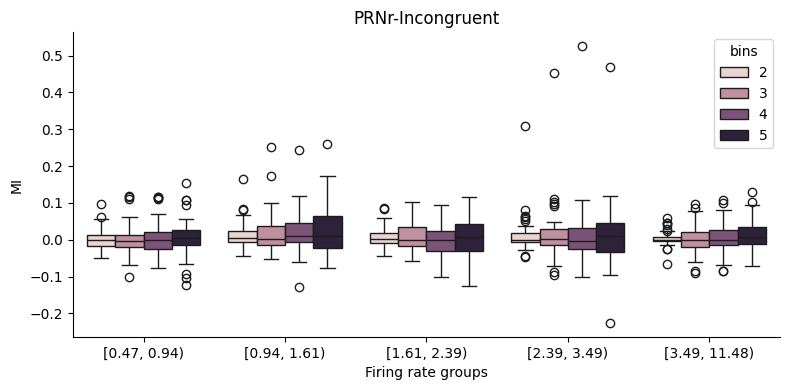

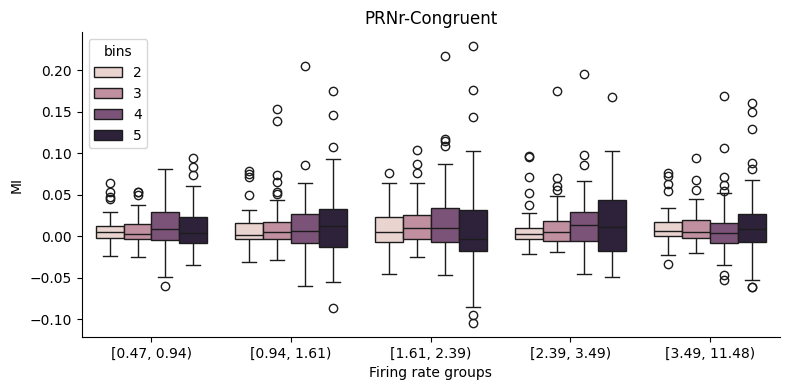

index 235 is out of bounds for axis 0 with size 47


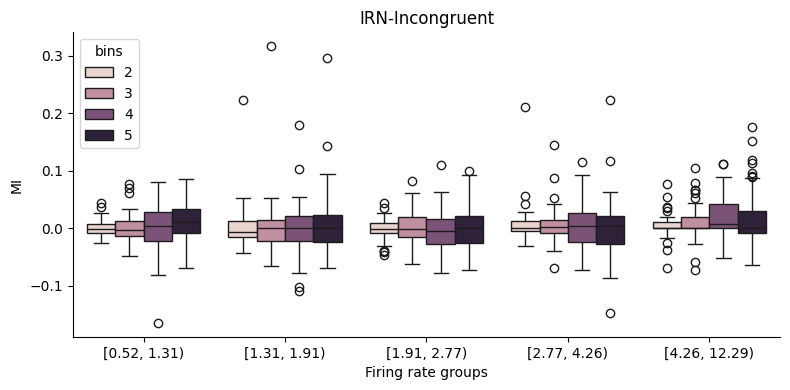

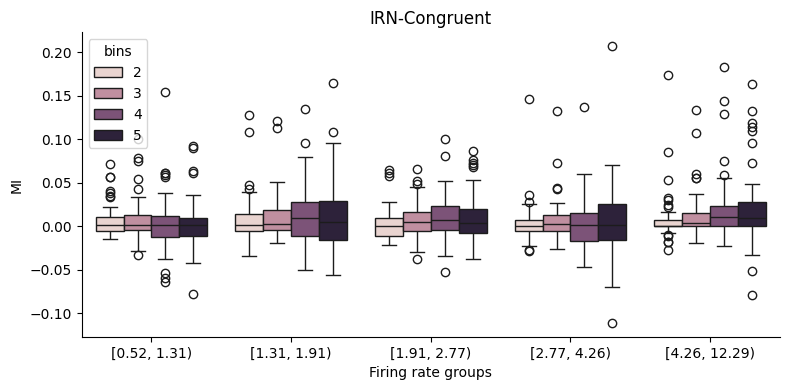

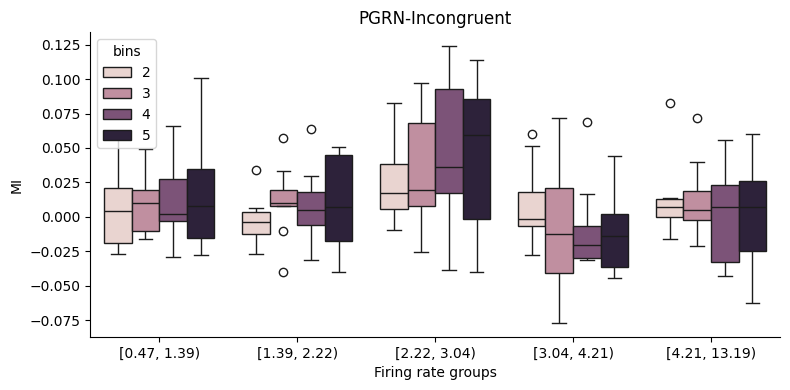

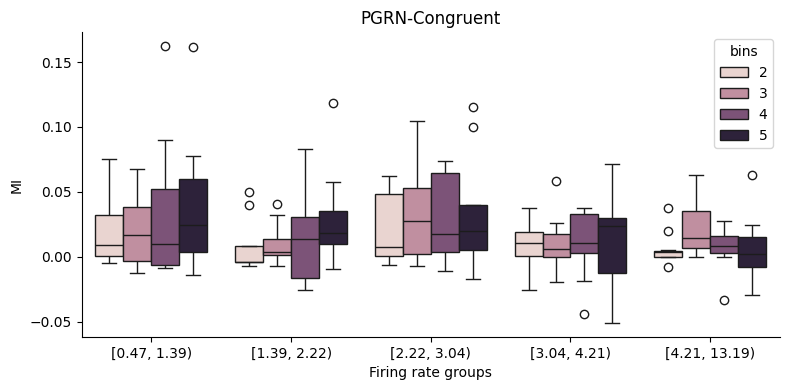

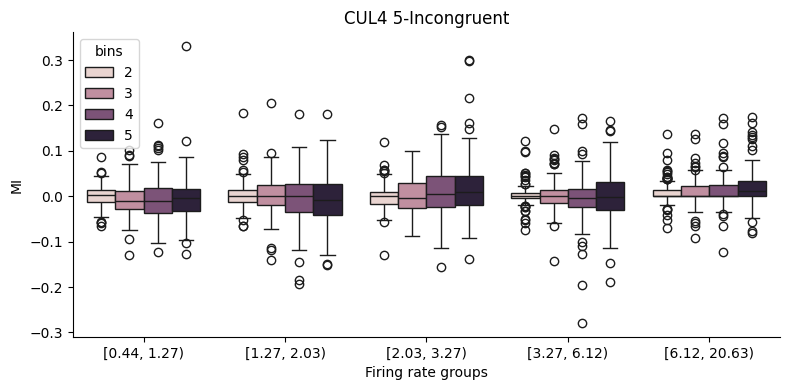

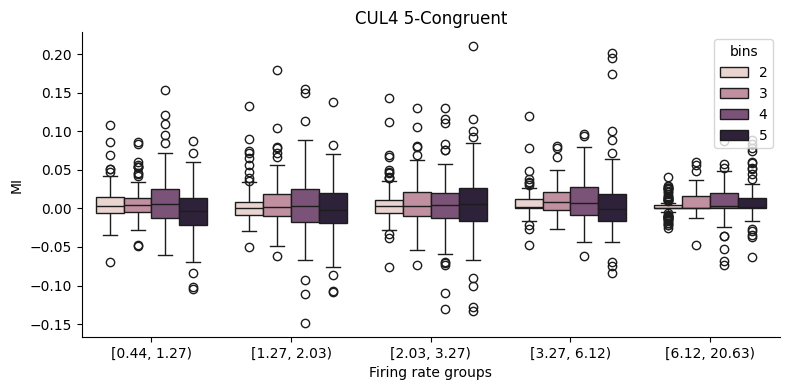

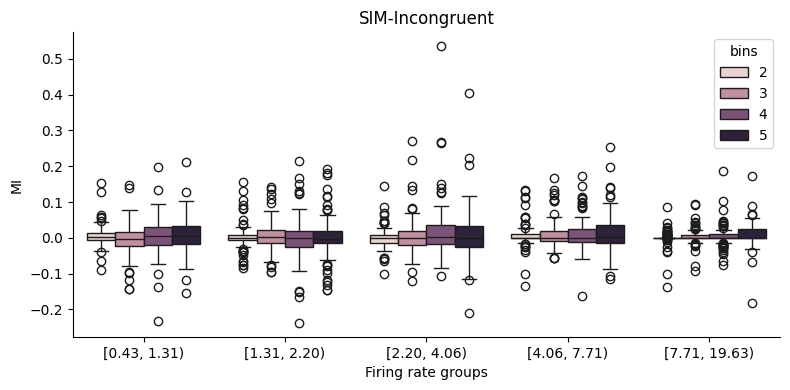

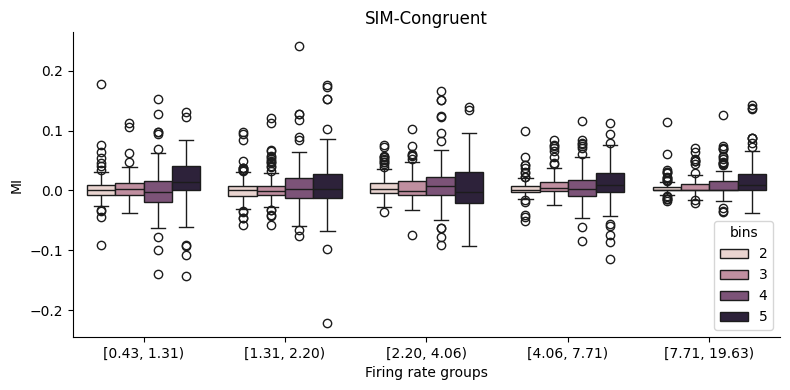

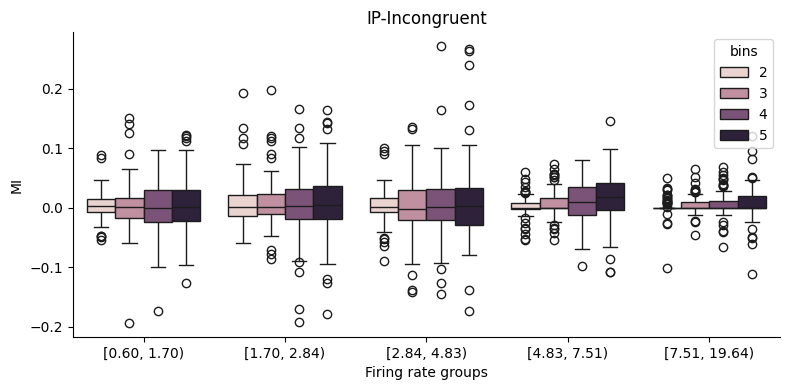

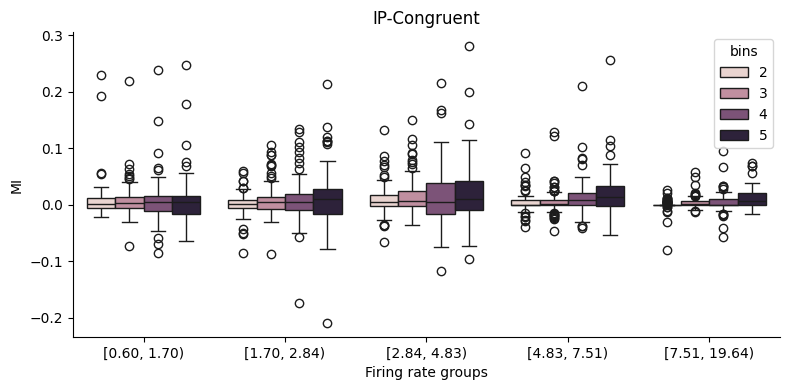

In [169]:
# now to plot BX

for idx in range(len(important_regions)):
    try:
        region = important_regions[idx]
        files = np.sort(
            glob(f"../../data/generated/nofilter/alternate/**/*{region}*.pkl", recursive=True)
        )
        BX = collate_by_bins(files, region)
        bins = len(files)
        if bins == 2:
            cg_sampled = np.asarray(
                [
                    BX[0][1],
                    BX[1][1],
                ]
            )
            icg_sampled = np.asarray(
                [
                    BX[0][2],
                    BX[1][2],
                ]
            )
        else:
            cg_sampled = np.asarray(
                [
                    BX[0][1],
                    BX[1][1],
                    BX[2][1],
                    BX[3][1],
                ]
            )
            icg_sampled = np.asarray(
                [
                    BX[0][2],
                    BX[1][2],
                    BX[2][2],
                    BX[3][2],
                ]
            )

        if bins == 2:
            bin_labels = [3, 4]
        elif bins == 4:
            bin_labels = [2, 3, 4, 5]

        plot_mi_vs_bins(
            BX[0][0],
            icg_sampled,
            bin_labels=bin_labels,
            n_groups=5,
            region=region,
            typeoftrial="Incongruent",
        )
        plot_mi_vs_bins(
            BX[0][0],
            cg_sampled,
            bin_labels=bin_labels,
            n_groups=5,
            region=region,
            typeoftrial="Congruent",
        )
    except Exception as e:
        print(e)
        continue

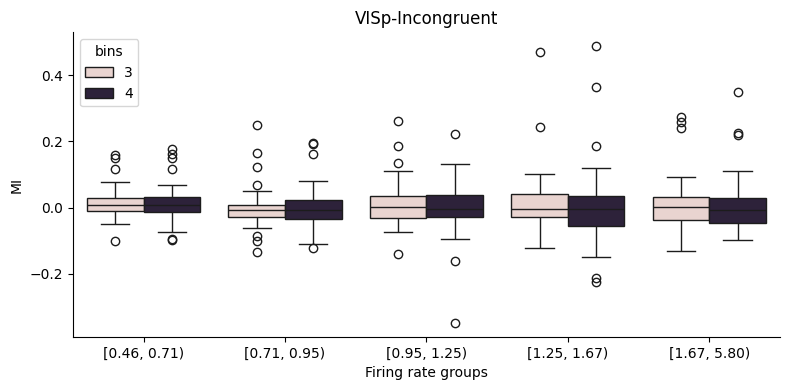

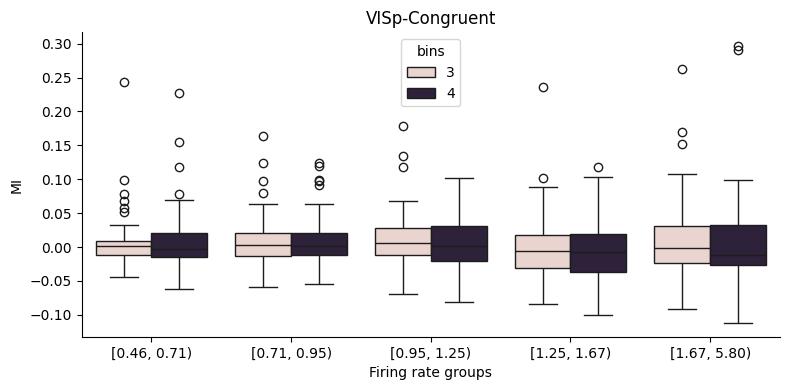

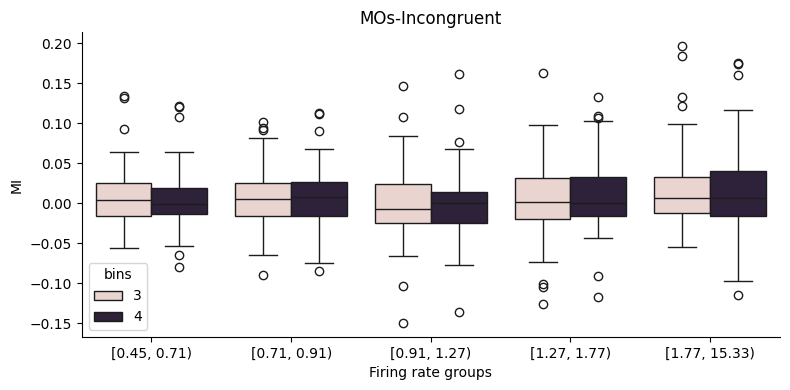

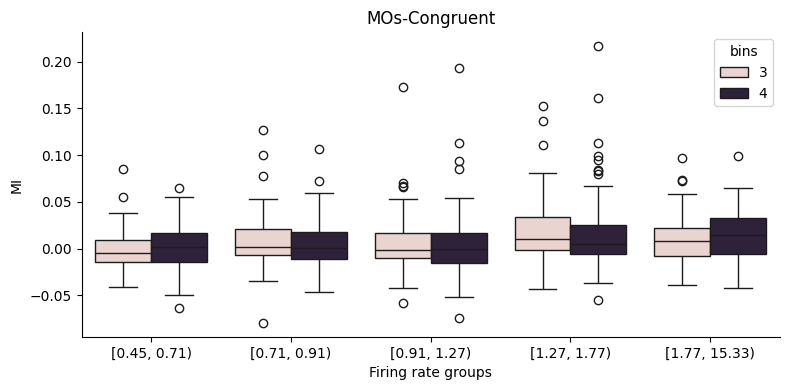

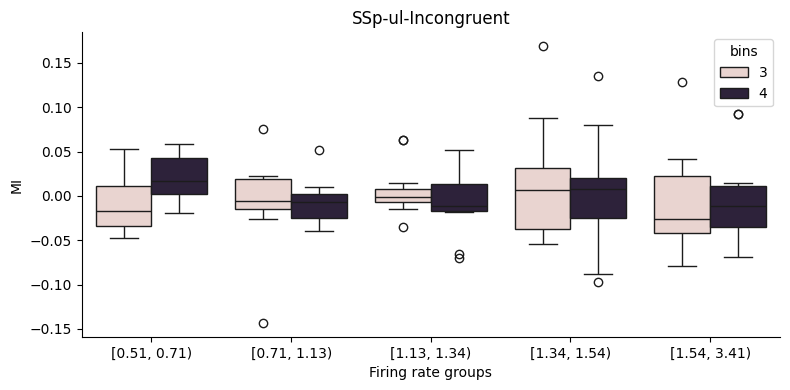

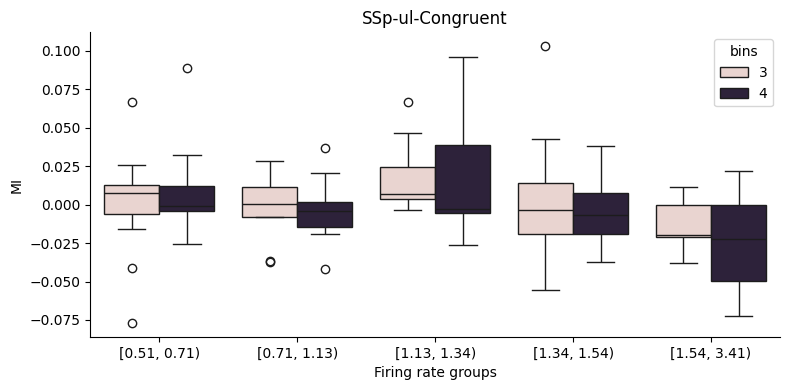

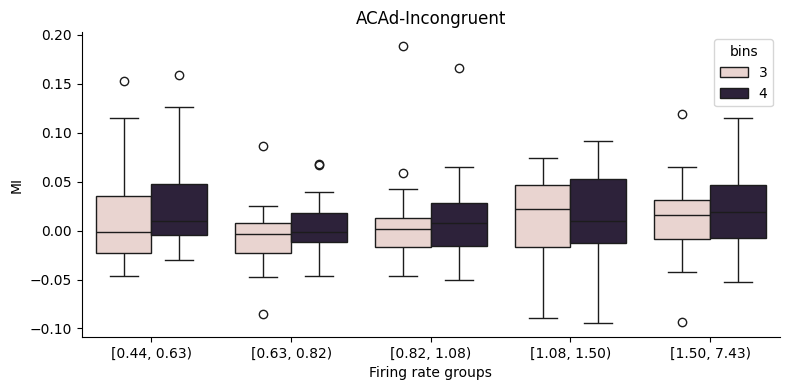

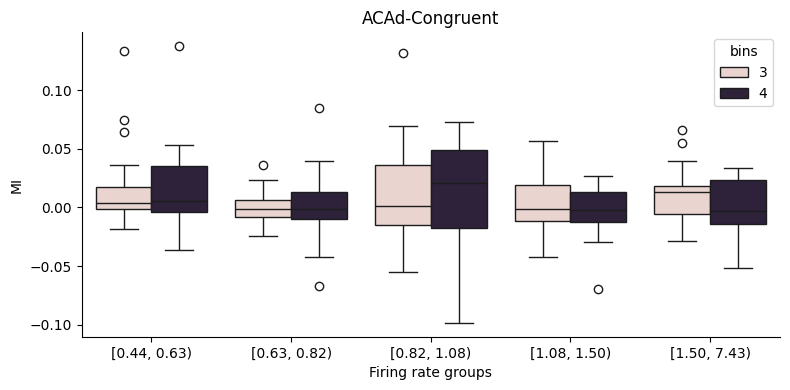

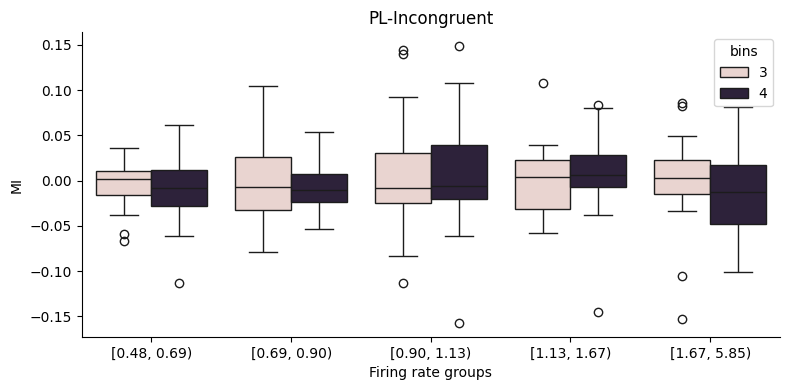

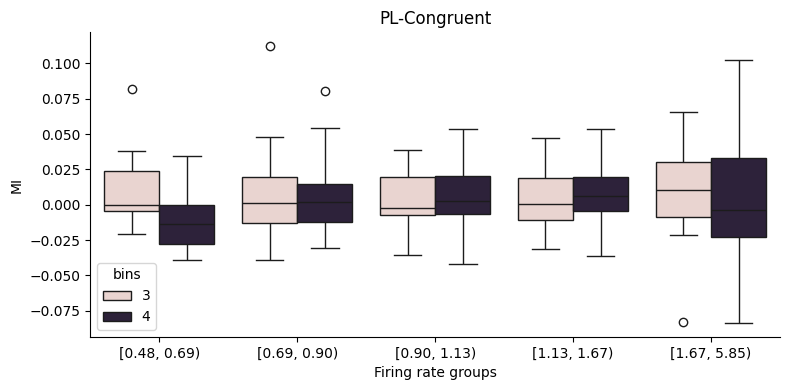

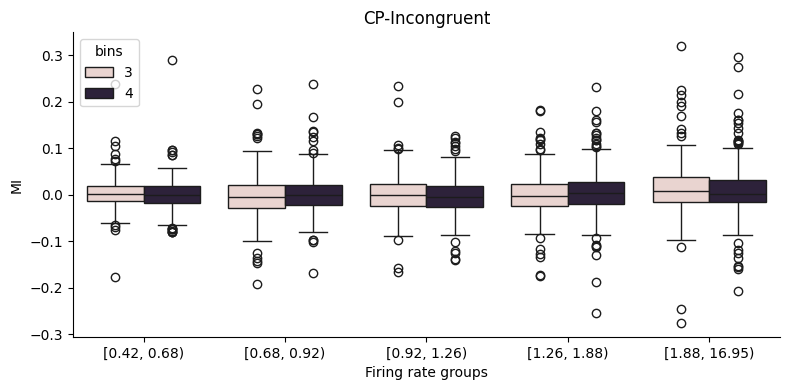

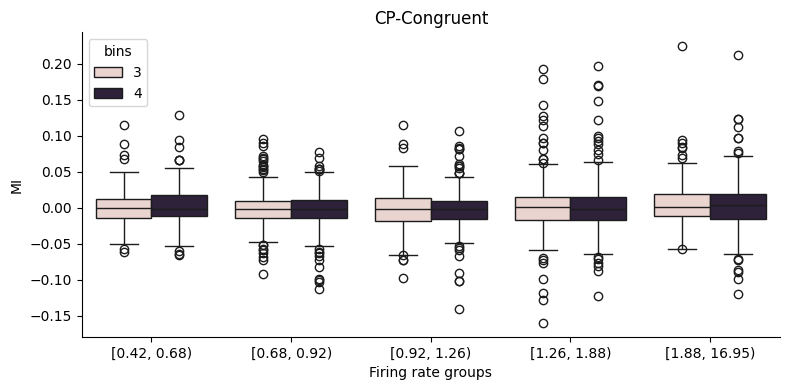

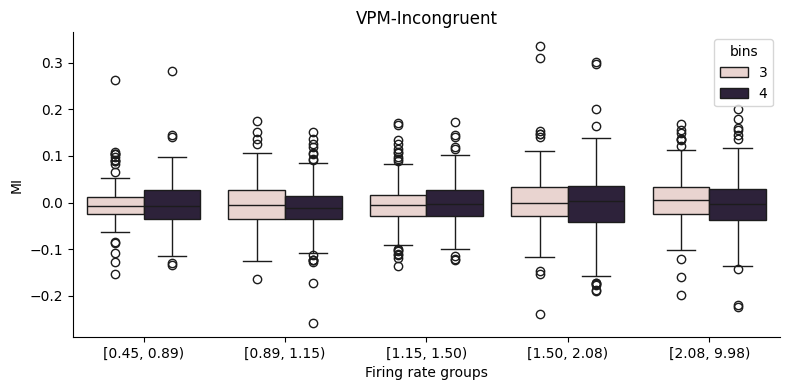

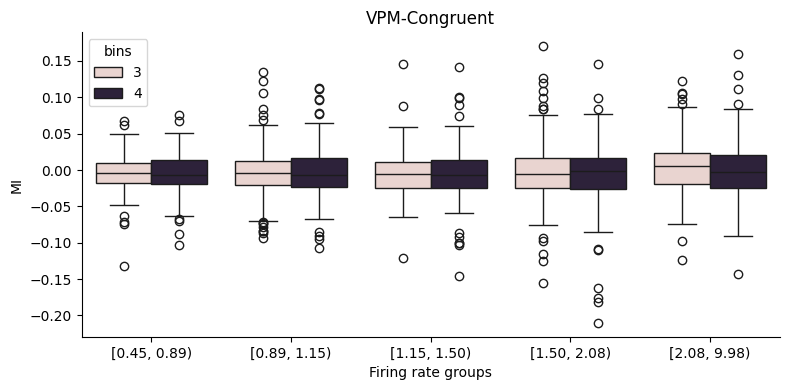

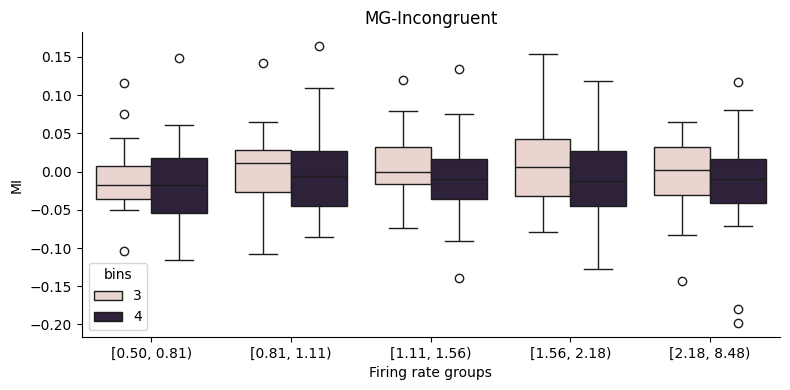

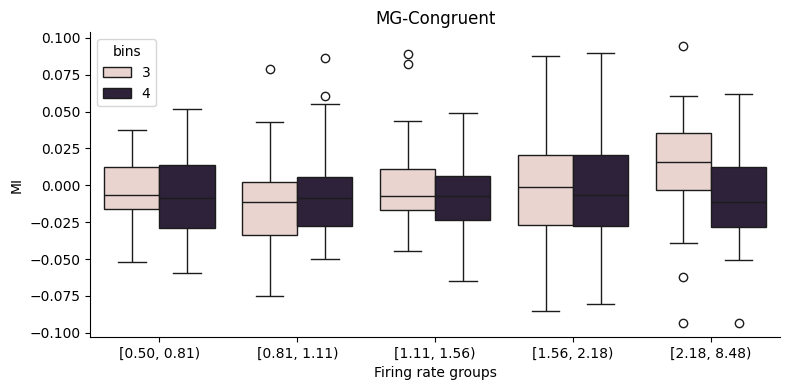

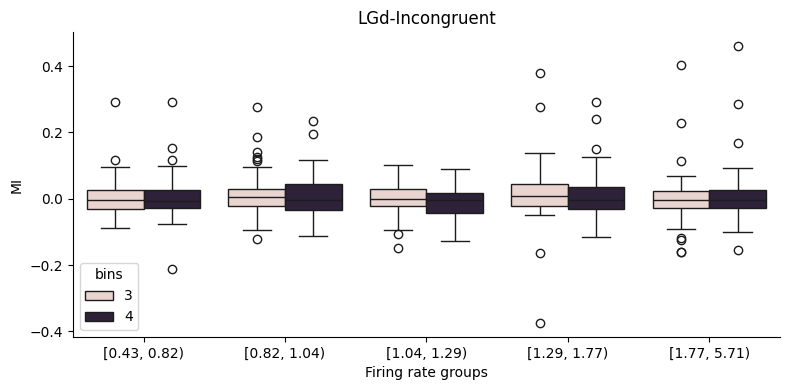

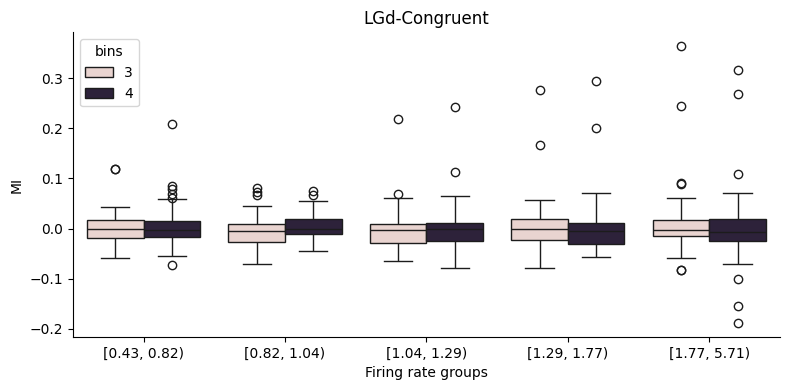

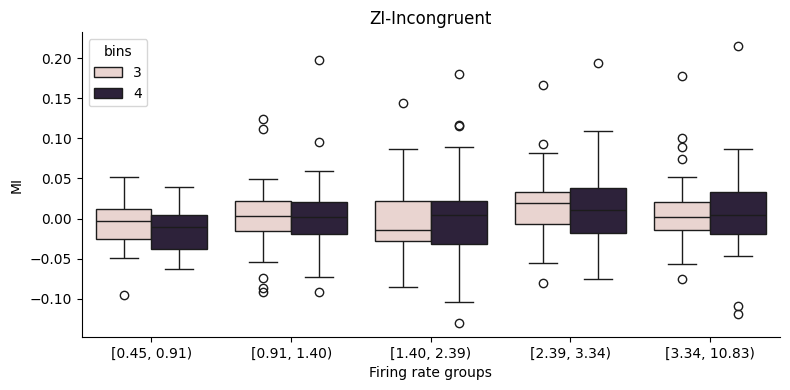

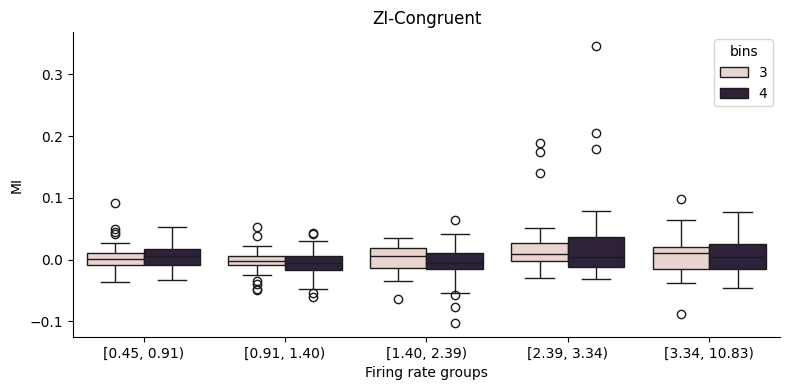

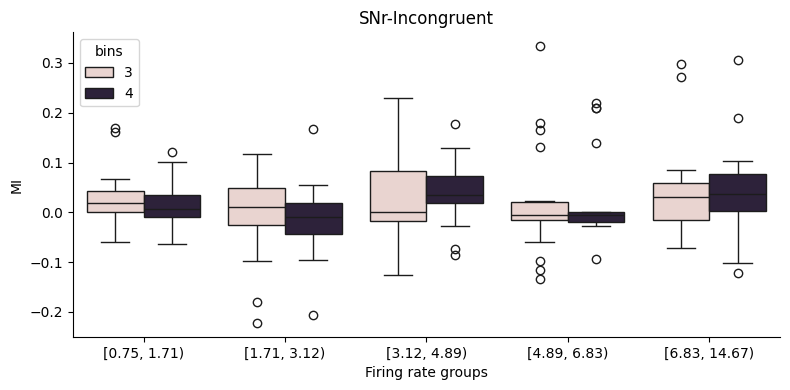

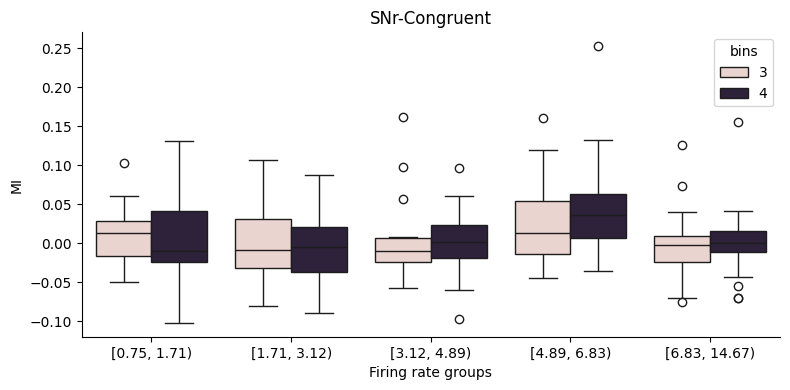

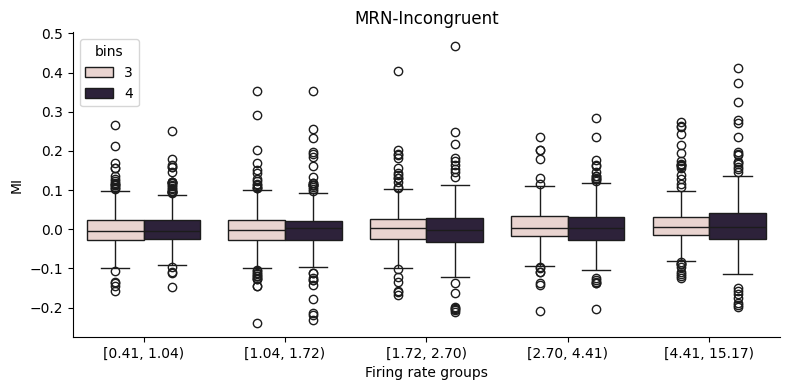

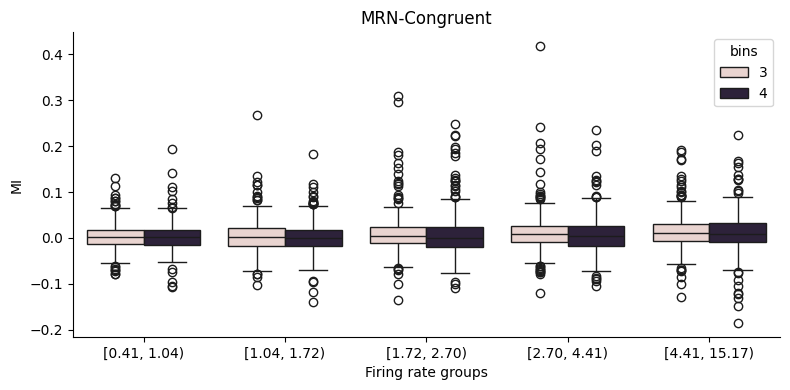

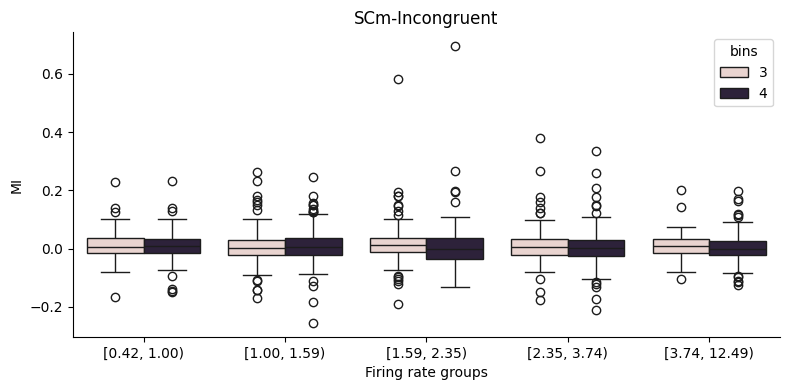

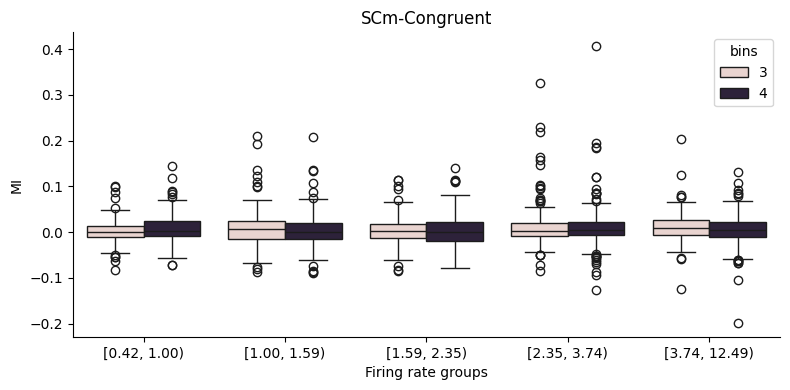

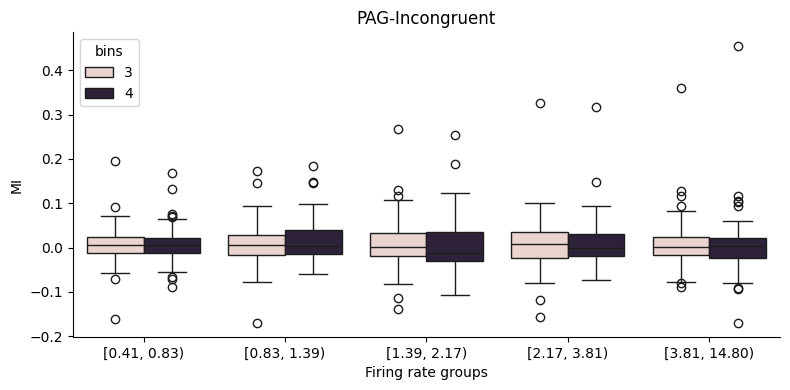

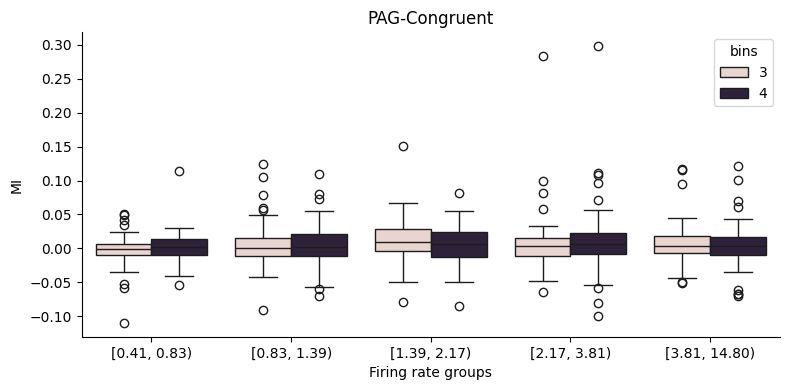

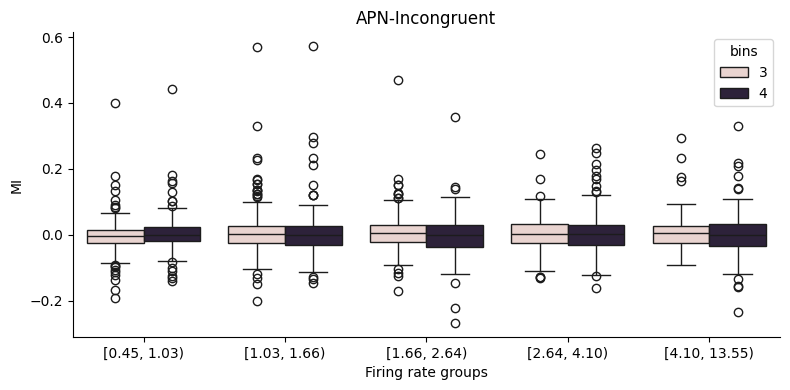

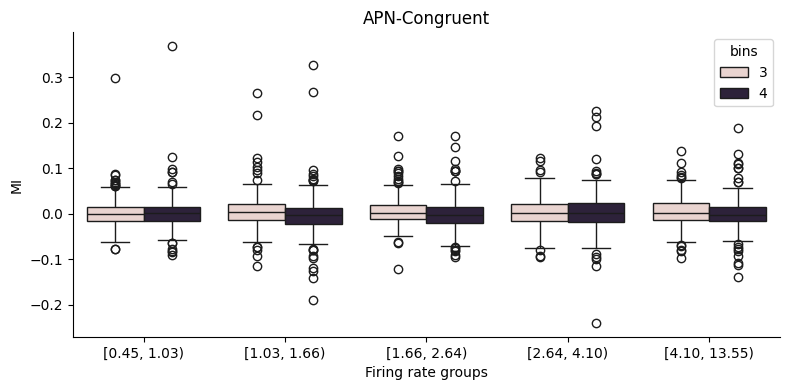

setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.


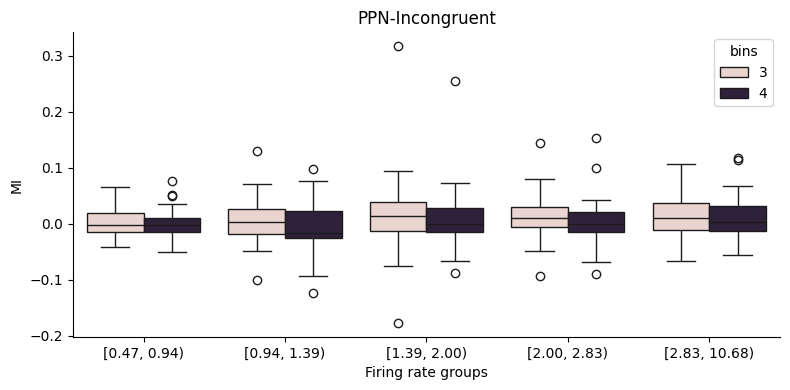

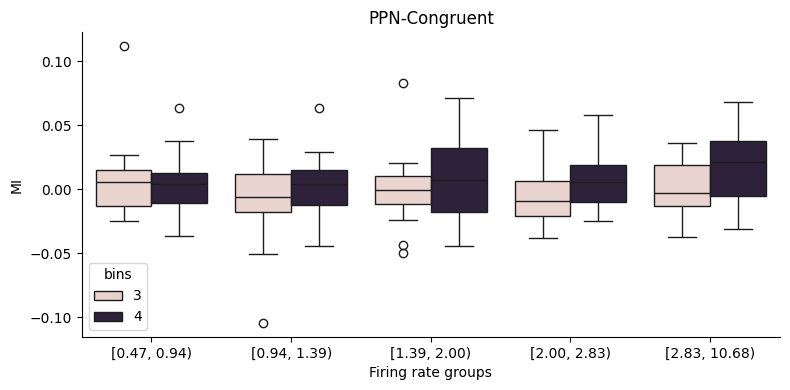

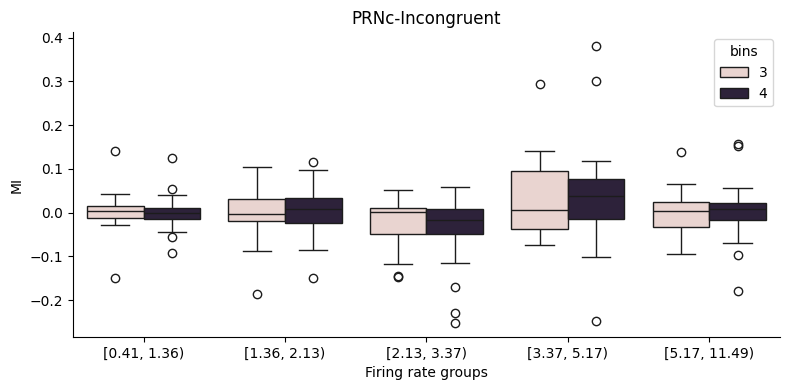

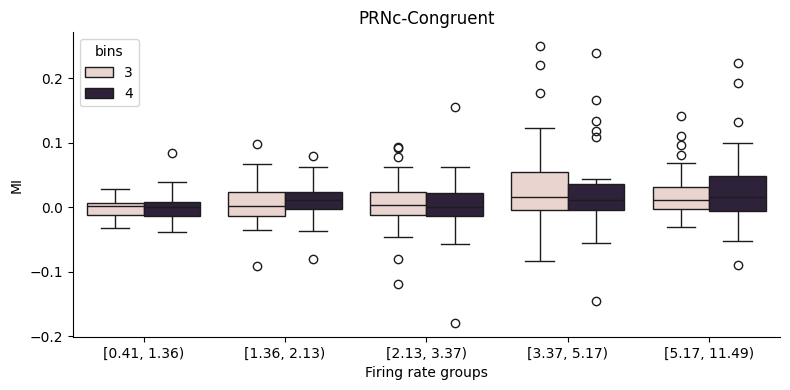

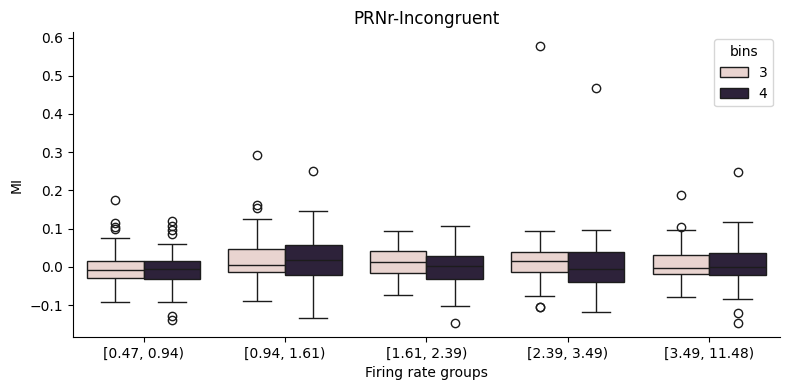

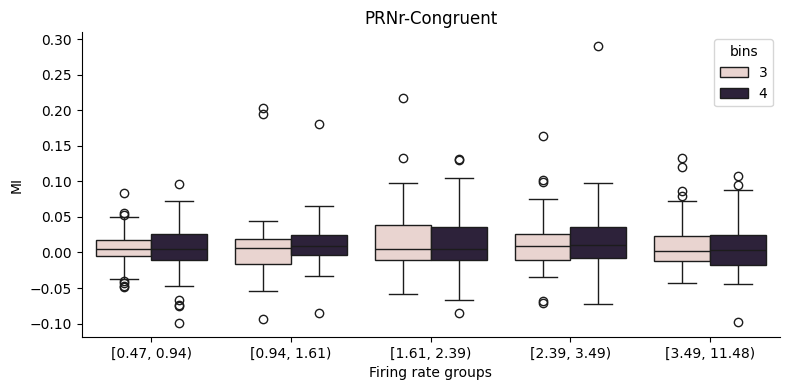

setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.


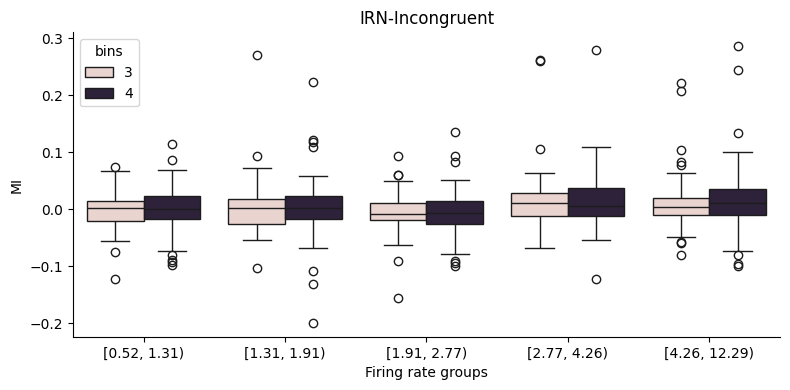

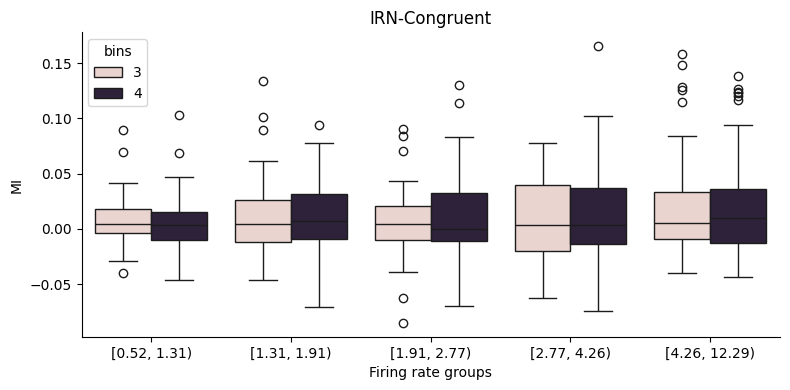

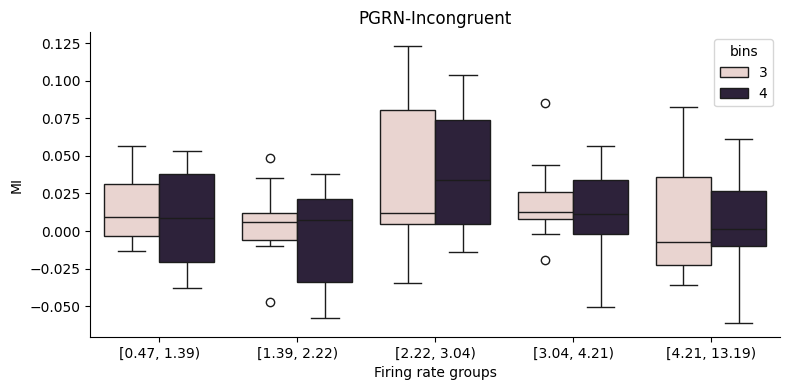

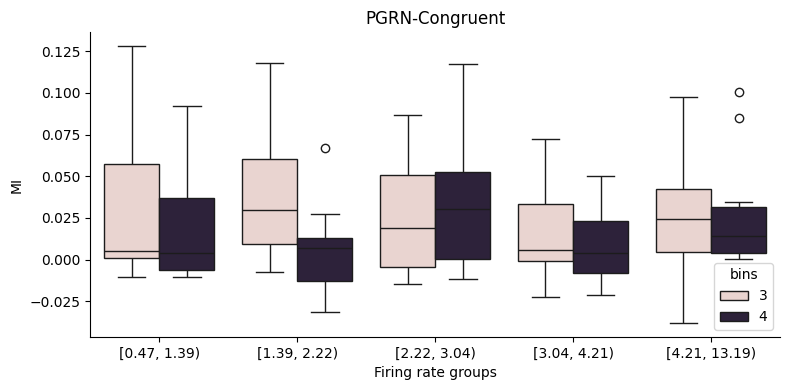

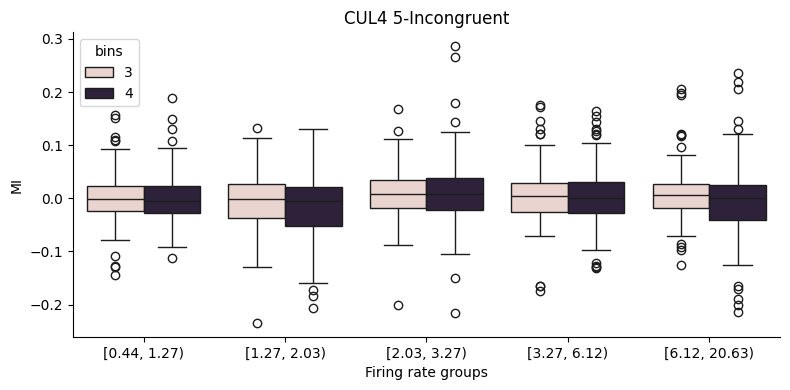

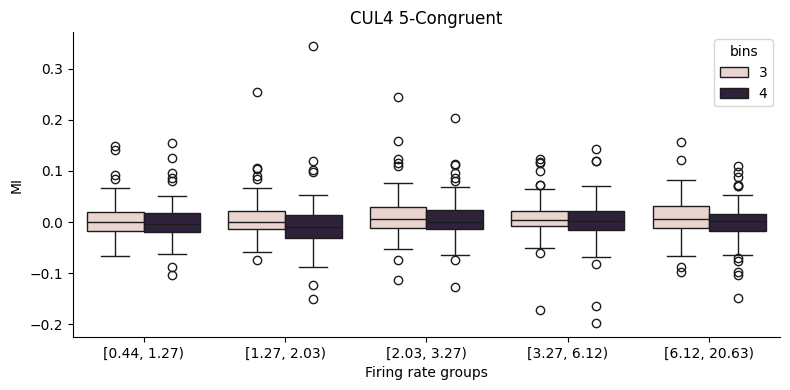

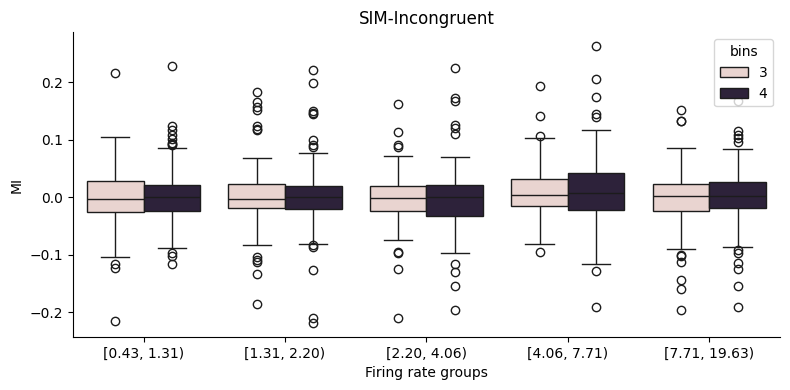

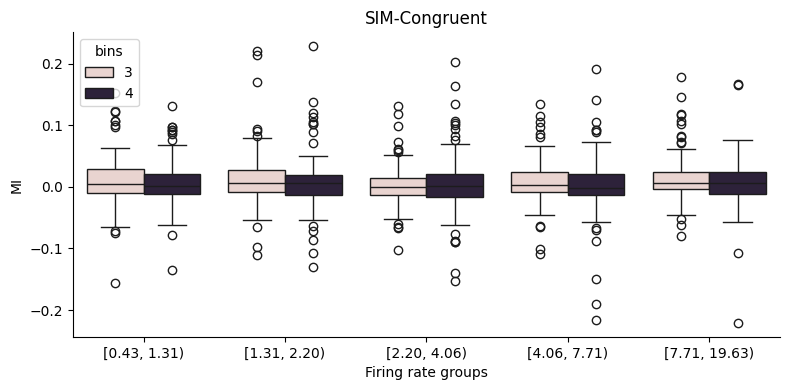

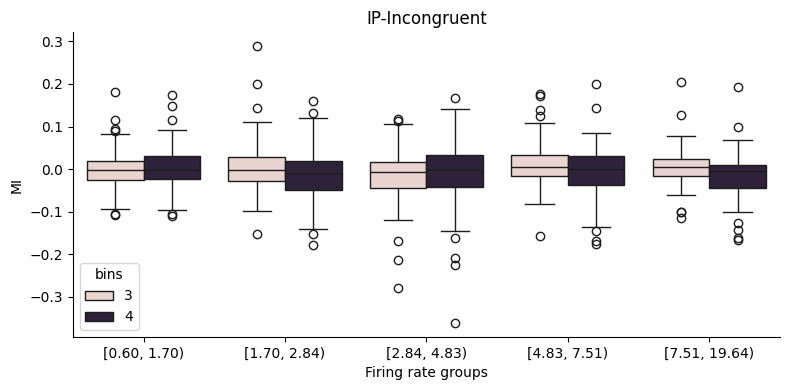

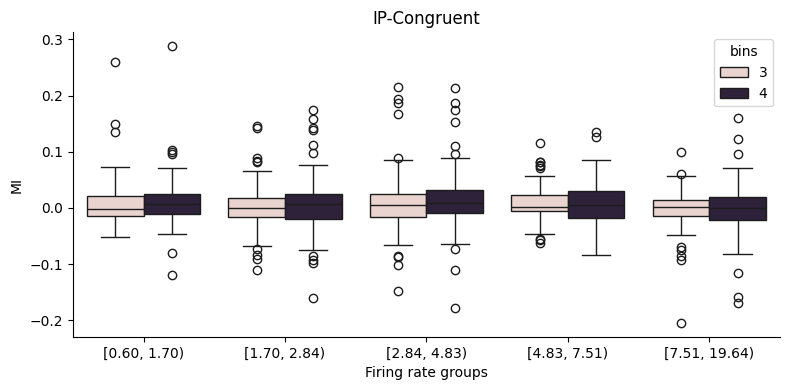

In [170]:
# now to plot BX

for idx in range(len(important_regions)):
    try:
        region = important_regions[idx]
        files = np.sort(
            glob(f"../../data/generated/nofilter/equi/**/*{region}*.pkl", recursive=True)
        )
        BX = collate_by_bins(files, region)
        bins = len(files)
        if bins == 2:
            cg_sampled = np.asarray(
                [
                    BX[0][1],
                    BX[1][1],
                ]
            )
            icg_sampled = np.asarray(
                [
                    BX[0][2],
                    BX[1][2],
                ]
            )
        else:
            cg_sampled = np.asarray(
                [
                    BX[0][1],
                    BX[1][1],
                    BX[2][1],
                    BX[3][1],
                ]
            )
            icg_sampled = np.asarray(
                [
                    BX[0][2],
                    BX[1][2],
                    BX[2][2],
                    BX[3][2],
                ]
            )

        if bins == 2:
            bin_labels = [3, 4]
        elif bins == 4:
            bin_labels = [2, 3, 4, 5]

        plot_mi_vs_bins(
            BX[0][0],
            icg_sampled,
            bin_labels=bin_labels,
            n_groups=5,
            region=region,
            typeoftrial="Incongruent",
        )
        plot_mi_vs_bins(
            BX[0][0],
            cg_sampled,
            bin_labels=bin_labels,
            n_groups=5,
            region=region,
            typeoftrial="Congruent",
        )
    except Exception as e:
        print(e)
        continue

In [144]:
files = glob(f"../../data/generated/nofilter/alternate/**/*{region}*.pkl", recursive=True)

In [150]:
len(np.sort(files))

4